# Matched comparison of vertebrate gene spectra

The reusable plotting functions receive a DataFrame that is **already restricted to the same species for every gene**. This notebook pools all vertebrate classes represented in the input and demonstrates the requested COX1-CytB comparison; change `GENES` to any 2-5 available genes to reuse the workflow.

`MutSpec` is an opportunity-adjusted, normalized 12-component spectrum weight. It is not a raw mutation rate. Mutation labels are complemented once here so all plots use heavy-strand notation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Find the repository from either its root or this analysis folder."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "1init_data" / "data" / "MutSpecVertebrates12.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


ROOT = find_project_root()
ANALYSIS_DIR = ROOT / "3compare_t_genes"
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from mutation_comparison import (
    DEFAULT_GENE_LABELS,
    orient_substitutions_to_heavy_strand,
    plot_matched_spectra,
    plot_mutation_comparison,
    select_common_species,
    validate_matched_spectra,
)

CLASS_FILTER = None  # Use an exact Class value here to analyse one class only.
GENES = ("CO1", "Cytb")  # Any 2-5 genes present in the input.
N_BOOT = 5_000
RANDOM_STATE = 20260722
DATA_PATH = ROOT / "1init_data" / "data" / "MutSpecVertebrates12.csv.gz"
DATA_DIR = ANALYSIS_DIR / "data"
FIGURES_DIR = ANALYSIS_DIR / "figures"
for directory in (DATA_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
spectra = pd.read_csv(DATA_PATH)
analysis_spectra = (
    spectra.copy()
    if CLASS_FILTER is None
    else spectra.loc[spectra["Class"].eq(CLASS_FILTER)].copy()
)
scope_label = "all vertebrates" if CLASS_FILTER is None else CLASS_FILTER
available_genes = sorted(analysis_spectra["Gene"].unique())

matched_raw, common_species = select_common_species(analysis_spectra, GENES)
matched = orient_substitutions_to_heavy_strand(matched_raw)
matched_info = validate_matched_spectra(matched, genes=GENES)

pair_slug = "_vs_".join(GENES)
matched_cohort = (
    matched_raw[["Species", "Class"]]
    .drop_duplicates()
    .sort_values(["Class", "Species"])
)
matched_cohort.to_csv(
    DATA_DIR / f"common_species_{pair_slug}.csv", index=False
)
matched.sort_values(["Species", "Gene", "Mut"]).to_csv(
    DATA_DIR / f"matched_spectra_{pair_slug}.csv", index=False
)

class_counts = (
    matched_cohort.groupby("Class", as_index=False)
    .size()
    .rename(columns={"size": "n_common_species"})
    .sort_values("n_common_species", ascending=False)
)

def common_count(*genes):
    if not set(genes).issubset(available_genes):
        return None
    species_sets = [
        set(analysis_spectra.loc[analysis_spectra["Gene"].eq(gene), "Species"])
        for gene in genes
    ]
    return len(set.intersection(*species_sets))

candidate_pair_counts = pd.DataFrame(
    [
        {"comparison": "COX3 / ND6", "data_labels": "CO3 / ND6",
         "n_common_vertebrates": common_count("CO3", "ND6"),
         "status": "ND6 spectrum is absent", "selected": False},
        {"comparison": "COX1 / CytB", "data_labels": "CO1 / Cytb",
         "n_common_vertebrates": common_count("CO1", "Cytb"),
         "status": "Available requested comparison",
         "selected": tuple(GENES) == ("CO1", "Cytb")},
        {"comparison": "COX3 / ND2", "data_labels": "CO3 / ND2",
         "n_common_vertebrates": common_count("CO3", "ND2"),
         "status": "Diagnostic only; ND2 is not ND6", "selected": False},
    ]
)
candidate_pair_counts.to_csv(DATA_DIR / "candidate_pair_counts.csv", index=False)

display(pd.DataFrame({"available_spectrum_genes": available_genes}))
display(class_counts.reset_index(drop=True))
print(
    f"Selected: {' / '.join(DEFAULT_GENE_LABELS.get(g, g) for g in GENES)}; "
    f"N = {matched_info.n_species} common species across {scope_label}."
)
print("ND6 is absent from this spectrum file and is not replaced by ND2.")

,available_spectrum_genes
0,CO1
1,CO3
2,Cytb
3,ND2


,Class,n_common_species
0,Mammalia,104
1,Actinopteri,35
2,Aves,27
3,Amphibia,8
4,Lepidosauria,4


Selected: COX1 / CytB; N = 178 common species across all vertebrates.
ND6 is absent from this spectrum file and is not replaced by ND2.


## Complete 12-component comparison

Points are means and whiskers are 95% cluster-bootstrap intervals obtained by resampling matched species. Categories are not connected because the 12 substitutions have no continuous x-axis.

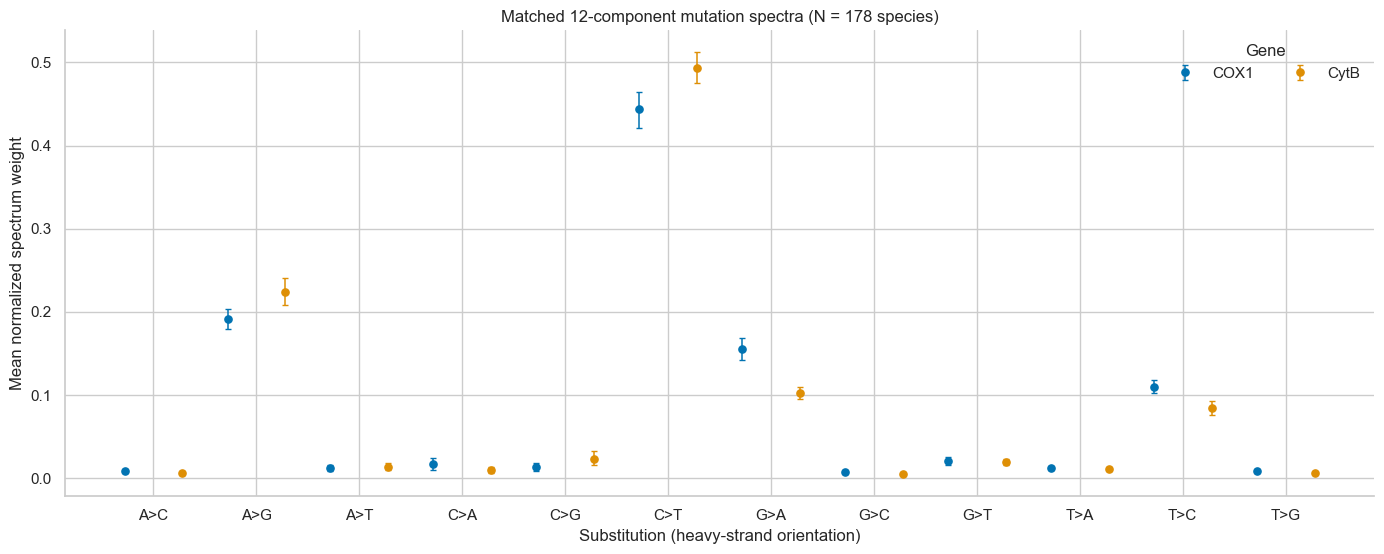

Gene,CO1,Cytb
Mut,,
A>C,0.0086,0.0064
A>G,0.1912,0.2238
A>T,0.0122,0.0137
C>A,0.0168,0.0094
C>G,0.0133,0.0237
C>T,0.4434,0.4937
G>A,0.1552,0.1028
G>C,0.0070,0.0056
G>T,0.0210,0.0195


In [3]:
spectrum_plot = plot_matched_spectra(
    matched, genes=GENES, n_boot=N_BOOT, random_state=RANDOM_STATE
)
spectrum_plot.fig.savefig(
    FIGURES_DIR / f"matched_12_component_{pair_slug}.png",
    dpi=300, bbox_inches="tight",
)
spectrum_plot.summary.to_csv(
    DATA_DIR / f"matched_12_component_summary_{pair_slug}.csv", index=False
)
plt.show()

display(
    spectrum_plot.summary.pivot(
        index="Mut", columns="Gene", values="estimate"
    ).loc[list(spectrum_plot.summary["Mut"].drop_duplicates())].round(4)
)

## Focus on heavy-strand C>T

Faint lines retain the within-species pairing. Boxes describe the observed distributions; diamonds and whiskers show mean weights and bootstrap intervals.

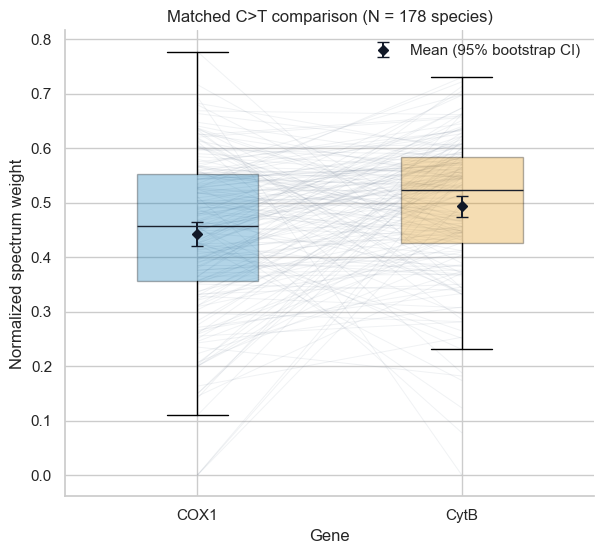

,Gene,Mut,n_species,estimate,ci_low,ci_high,estimator,confidence
5,CO1,C>T,178,0.44341,0.42130,0.46467,mean,0.95
17,Cytb,C>T,178,0.49371,0.47473,0.51292,mean,0.95


In [4]:
ct_plot = plot_mutation_comparison(
    matched, "C>T", genes=GENES, n_boot=N_BOOT, random_state=RANDOM_STATE
)
ct_plot.fig.savefig(
    FIGURES_DIR / f"matched_CT_{pair_slug}.png",
    dpi=300, bbox_inches="tight",
)
plt.show()
display(ct_plot.summary.round(5))

The comparison is descriptive: species are paired but phylogenetically non-independent, and the 12 normalized components are compositional. Publication-level inference should therefore use a phylogeny-aware compositional model rather than independent per-component tests.